In [3]:
import os
from PyPDF2 import PdfReader  # pip install PyPDF2 if not already installed
import pickle

# Path to the directory containing PDF files (and subfolders)
root_folder = "./LawsDocs/PDFs_URLCodes_entryDate"

def count_pdfs(folder_path):
    pdf_count = 0
    for root, dirs, files in os.walk(folder_path):
        # Count only PDF files that include "legge federale" in their filename (case-insensitive)
        pdf_count += sum(1 for file in files if file.lower().endswith(".pdf") and "legge federale" in file.lower())
    return pdf_count

def get_pdf_page_counts(folder_path):
    """
    Walk through the folder and count pages for each PDF,
    only considering PDFs whose filename contains "legge federale",
    and store the results in a dictionary using the PDF title.
    """
    pdf_pages = {}    # Dictionary: PDF title -> page count
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".pdf") and "legge federale" in file.lower():
                pdf_title = os.path.splitext(file)[0]
                file_path = os.path.join(root, file)
                try:
                    reader = PdfReader(file_path)
                    page_count = len(reader.pages)
                    pdf_pages[pdf_title] = page_count
                except Exception as e:
                    print(f"Error processing '{file_path}': {e}")
    return pdf_pages

total_pdfs = count_pdfs(root_folder)
print(f"Total number of PDF files containing 'legge federale': {total_pdfs}")

# Get the page counts for each PDF in a dictionary
pdf_page_counts = get_pdf_page_counts(root_folder)

print(pdf_page_counts)

# print the average number of pages
average_pages = sum(pdf_page_counts.values()) / len(pdf_page_counts) if pdf_page_counts else 0
print(f"Average number of pages in PDF files containing 'legge federale': {average_pages:.2f}")

# Save the dictionary to a file
with open("pdf_page_counts.pkl", "wb") as f:
    pickle.dump(pdf_page_counts, f)

Total number of PDF files containing 'legge federale': 1065
{'212_01.07_Legge federale': 10, '726_01.01_Legge federale': 8, '688_01.01_Legge federale': 2, '641_01.01_Legge federale': 2, '33_01.02_Legge federale': 22, '86_01.04_Legge federale': 2, '678_01.01_Legge federale': 4, '84_01.01_Legge federale': 4, '682_01.01_Legge federale': 4, '355_01.01_Legge federale': 16, '200_01.06_Legge federale': 2, '680_01.01_Legge federale': 20, '257_01.07_Legge federale': 4, '453_01.10_Legge federale': 16, '118_01.04_Legge federale': 18, '734_01.01_Legge federale': 8, '630_01.01_Legge federale': 6, '131_01.05_Legge federale': 8, '501_01.10_Legge federale': 2, '655_01.01_Legge federale': 8, '188_01.06_Legge federale': 8, '457_01.10_Legge federale': 22, '468_01.01_Legge federale': 6, '731_01.01_Legge federale': 8, '804_01.02_Legge federale': 4, '424_01.09_Legge federale': 4, '450_09.09_Legge federale': 2, '531_01.01_Legge federale': 6, '452_01.01_Legge federale': 8, '119_01.01_Legge federale': 4, '186_

In [6]:
# create a dictionary with the number of pages for each PDF
pdf_page_counts_dict = {}
for pdf_title, page_count in pdf_page_counts.items():
    pdf_page_counts_dict[pdf_title] = page_count

# order the dictionary by the number of pages desc
pdf_page_counts_dict = dict(sorted(pdf_page_counts_dict.items(), key=lambda item: item[1], reverse=True))
# print the ordered dictionary
print("Ordered PDF page counts:")
for pdf_title, page_count in pdf_page_counts_dict.items():
    print(f"{pdf_title}: {page_count} pages")


Ordered PDF page counts:
267_01.01_Legge federale: 168 pages
352_01.01_Legge federale: 94 pages
491_01.09_Legge federale: 90 pages
510_01.01_Legge federale: 82 pages
549_01.01_Legge federale: 80 pages
746_01.01_Legge federale: 72 pages
801_01.01_Legge federale: 60 pages
510_01.12_Legge federale: 58 pages
114_01.01_Legge federale: 58 pages
249_01.05_Legge federale: 58 pages
822_01.01_Legge federale: 58 pages
259_01.07_Legge federale: 56 pages
494_01.09_Legge federale: 56 pages
3033_01.01_Legge federale: 55 pages
600_23.01_Legge federale: 54 pages
472_01.01_Legge federale: 54 pages
795_01.01_Legge federale: 52 pages
320_01.07_Legge federale: 52 pages
762_01.01_Legge federale: 50 pages
823_01.01_Legge federale: 50 pages
126_01.01_Legge federale: 50 pages
150_01.04_Legge federale: 50 pages
218_01.01_Legge federale: 48 pages
736_01.01_Legge federale: 48 pages
212_01.01_Legge federale: 47 pages
422_01.01_Legge federale: 44 pages
232_01.05_Legge federale: 44 pages
787_01.01_Legge federale: 40

Distribution of page counts:
1 pages: 7 files
2 pages: 306 files
3 pages: 23 files
4 pages: 185 files
5 pages: 10 files
6 pages: 63 files
7 pages: 10 files
8 pages: 46 files
9 pages: 1 files
10 pages: 52 files
11 pages: 2 files
12 pages: 29 files
13 pages: 1 files
14 pages: 27 files
15 pages: 1 files
16 pages: 24 files
18 pages: 24 files
20 pages: 15 files
22 pages: 10 files
24 pages: 12 files
26 pages: 8 files
27 pages: 1 files
28 pages: 6 files
30 pages: 6 files
32 pages: 5 files
34 pages: 5 files
36 pages: 2 files
40 pages: 5 files
44 pages: 2 files
47 pages: 1 files
48 pages: 2 files
50 pages: 4 files
52 pages: 2 files
54 pages: 2 files
55 pages: 1 files
56 pages: 2 files
58 pages: 4 files
60 pages: 1 files
72 pages: 1 files
80 pages: 1 files
82 pages: 1 files
90 pages: 1 files
94 pages: 1 files
168 pages: 1 files
Total number of files in distribution: 913


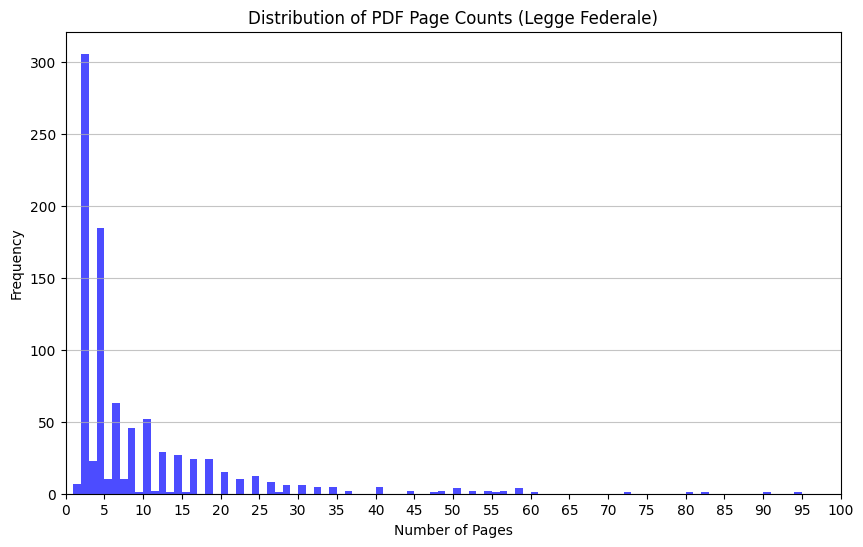

In [2]:
import pickle

# Load the dictionary from the file
with open("pdf_page_counts.pkl", "rb") as f:
    loaded_pdf_page_counts = pickle.load(f)

# print the distribution of page counts
page_count_distribution = {}
for count in loaded_pdf_page_counts.values():
    if count not in page_count_distribution:
        page_count_distribution[count] = 0
    page_count_distribution[count] += 1
print("Distribution of page counts:")
for count, freq in sorted(page_count_distribution.items()):
    print(f"{count} pages: {freq} files")
# Print the total number of files in the distribution
total_files_in_distribution = sum(page_count_distribution.values())
print(f"Total number of files in distribution: {total_files_in_distribution}")
# plot the distribution
import matplotlib.pyplot as plt
import numpy as np
# Create a histogram of the page counts and cut off the outliers over 100
plt.figure(figsize=(10, 6))
plt.hist(list(loaded_pdf_page_counts.values()), bins=range(1, 101), color='blue', alpha=0.7)
plt.title("Distribution of PDF Page Counts (Legge Federale)")
plt.xlabel("Number of Pages")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.xticks(np.arange(0, 101, 5))
plt.xlim(0, 100)
plt.show()


In [13]:
# open ./LawsDocs/PDFs_URLCodes_entryDate/2010/35_01.02_Legge federale.pdf with fitz and put the text in a variable
import fitz  # pip install PyMuPDF if not already installed
def extract_text_from_pdf(file_path):
    """
    Extract text from a PDF file using PyMuPDF (fitz).
    """
    text = ""
    try:
        with fitz.open(file_path) as doc:
            for page in doc:
                text += page.get_text()
    except Exception as e:
        print(f"Error processing '{file_path}': {e}")
    return text
# Example usage
file_path = "./LawsDocs/PDFs_URLCodes_entryDate/2010/35_01.02_Legge federale.pdf"
text = extract_text_from_pdf(file_path)
# Save the text to a file
with open("extracted_text.txt", "w", encoding="utf-8") as f:
    f.write(text)

Stats loaded: 21402 laws processed.
Overall Sections Distribution Statistics:
  Minimum: 1
  Maximum: 6536
  Mean: 18.22
  Median: 4.0
Statistics for number of sections <= 20
  Minimum: 1
  Maximum: 15
  Mean: 4.46
  Median: 4.0
Statistics for number of sections > 20
  Minimum: 16
  Maximum: 6536
  Mean: 64.53
  Median: 34.0


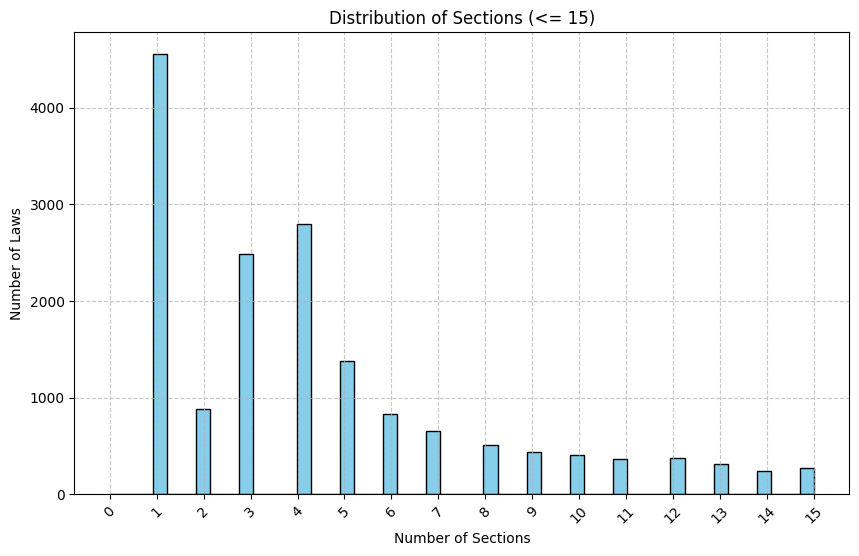

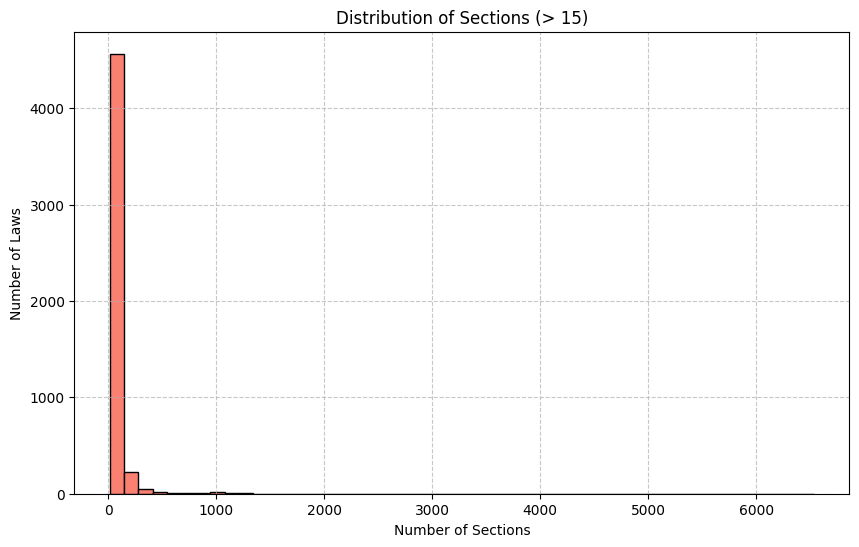

Number of empty sections: 0


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

with open("pdf_laws_analysis_stats.json", "r", encoding="utf-8") as stats_file:
    stats = json.load(stats_file)
print(f"Stats loaded: {len(stats)} laws processed.")
# find the distribution of the number of sections
num_sections = [law_data["num_sections"] for law_data in stats.values()]

threshold = 15
sections_low = [length for length in num_sections if length <= threshold]
sections_high = [length for length in num_sections if length > threshold]

# Compute statistics for overall
minimum = np.min(num_sections)
maximum = np.max(num_sections)
mean = np.mean(num_sections)
median = np.median(num_sections)

print("Overall Sections Distribution Statistics:")
print(f"  Minimum: {minimum}")
print(f"  Maximum: {maximum}")
print(f"  Mean: {mean:.2f}")
print(f"  Median: {median}")

minimum = np.min(sections_low)
maximum = np.max(sections_low)
mean = np.mean(sections_low)
median = np.median(sections_low)

print("Statistics for number of sections <= 20")
print(f"  Minimum: {minimum}")
print(f"  Maximum: {maximum}")
print(f"  Mean: {mean:.2f}")
print(f"  Median: {median}")

minimum = np.min(sections_high)
maximum = np.max(sections_high)
mean = np.mean(sections_high)
median = np.median(sections_high)

print("Statistics for number of sections > 20")
print(f"  Minimum: {minimum}")
print(f"  Maximum: {maximum}")
print(f"  Mean: {mean:.2f}")
print(f"  Median: {median}")


# Plot histogram for laws <= 10,000 with smaller x-axis intervals
plt.figure(figsize=(10, 6))
bins_low = np.linspace(0, threshold, 50)  # 50 bins up to 10,000
plt.hist(sections_low, bins=bins_low, color="skyblue", edgecolor="black")
plt.xlabel("Number of Sections")
plt.ylabel("Number of Laws")
plt.title("Distribution of Sections (<= 15)")
plt.grid(True, linestyle="--", alpha=0.7)
# Set x-axis ticks at intervals of 1000 (adjust if needed)
ticks_low = np.arange(0, threshold+1, 1)
plt.xticks(ticks_low, rotation=45)
plt.show()

# Plot histogram for laws > 10,000 text lengths
plt.figure(figsize=(10, 6))
# Create 50 bins between threshold and maximum value
bins_high = np.linspace(threshold, max(sections_high), 50) if sections_high else []
if bins_high.size > 0:
    plt.hist(sections_high, bins=bins_high, color="salmon", edgecolor="black")
    plt.xlabel("Number of Sections")
    plt.ylabel("Number of Laws")
    plt.title("Distribution of Sections (> 15)")
    plt.grid(True, linestyle="--", alpha=0.7)
    # Set x-axis ticks: here we choose an interval so that there are around 10 ticks
    tick_interval = (max(sections_high) - threshold) / 10
    ticks_high = np.arange(threshold, max(sections_high)+tick_interval, tick_interval)
    plt.show()
else:
    print("No laws found with text length greater than 10,000.")

# find the number of empy sections
empty_sections = [law_data["num_sections"] for law_data in stats.values() if law_data["num_sections"] == 0]
print(f"Number of empty sections: {len(empty_sections)}")
# find the number of sections with references


In [20]:

# sum the number of sections for every law
sum_sections = sum(law_data["num_sections"] for law_data in stats.values())
print(f"Total number of sections: {sum_sections}")

# sum the number of references for every law
sum_references = sum(law_data["total_references"] for law_data in stats.values())
print(f"Total number of references: {sum_references}")

Total number of sections: 389946
Total number of references: 69699


# I want to find out which pdf reader is the best

In [25]:
pdf_file = "./LawsDocs/PDFs_URLCodes_entryDate/2007/284_01.01_Legge federale.pdf"

### Let's start with pypdf

In [2]:
import pypdf
import os

def extract_text_with_pypdf(pdf_path):
    """Extracts text from a PDF using the pypdf library."""
    print(f"\n--- Using pypdf ---")
    if not os.path.exists(pdf_path):
        print(f"Error: File not found at {pdf_path}")
        return None

    try:
        reader = pypdf.PdfReader(pdf_path)
        full_text = ""
        for i, page in enumerate(reader.pages):
            try:
                page_text = page.extract_text()
                if page_text: # Check if text extraction returned something
                     full_text += page_text + "\n" + "page_break" + "\n\n"
                else:
                     print(f"Warning: No text extracted from page {i+1}")
            except Exception as page_e:
                print(f"Error extracting text from page {i+1}: {page_e}")
        return full_text.strip() # Remove leading/trailing whitespace
    except pypdf.errors.PdfReadError as e:
         print(f"Error reading PDF (is it encrypted or corrupted?): {e}")
         return None
    except Exception as e:
        print(f"An unexpected error occurred with pypdf: {e}")
        return None

extracted_pypdf_text = extract_text_with_pypdf(pdf_file)
print(extracted_pypdf_text)


--- Using pypdf ---
2007-1018 2819 
Ordinanza 
sulla gestione immobiliare e la logistica  
della Confederazione 
(OILC) 
Modifica del 16 maggio 2007 
 
Il Consiglio federale svizzero 
ordina: 
I 
L’ordinanza del 14 dicembre 1998 1 sulla gestione immobilia re e la logistica della 
Confederazione è modificata come segue: 
Art. 3b Collaborazione con i Tribunali della Confederazione 
1 Il Dipartimento federale delle finanze (D FF) è autorizzato a concludere le conven-
zioni di cui agli articoli 25 a della legge federale del 17 giugno 2005 2 sul Tribunale 
federale, 27a della legge del 17 giugno 2005 3 sul Tribunale amministrativo federale 
e 23a della legge del 4 ottobre 20024 sul Tribunale penale federale. 
2 Le convenzioni e le loro modifiche im portanti necessitano della previa approva-
zione del Consiglio federale. Qualora si tratti di questioni tecnico-amministrative 
che non provocano costi finanziari signifi cativi, il DFF può concordare in modo 
autonomo adeguamenti con i Tribunal

### This one is pymupdf (fitz)

In [1]:
pdf_file = "./LawsDocs/PDFs_URLCodes_entryDate/2007/368_01.07_Ordinanza del Consiglio federale.pdf"

import fitz # PyMuPDF library is imported as fitz
import os

def extract_text_with_pymupdf(pdf_path):
    """Extracts text from a PDF using the PyMuPDF (fitz) library."""
    print(f"\n--- Using PyMuPDF (fitz) ---")
    if not os.path.exists(pdf_path):
        print(f"Error: File not found at {pdf_path}")
        return None

    full_text = ""
    try:
        # Use a context manager to ensure the file is closed
        with fitz.open(pdf_path) as doc:
            for i, page in enumerate(doc): # Iterate through pages
                try:
                    page_text = page.get_text()
                    if page_text:
                        full_text += page_text + "\n" + "page_break" + "\n"
                    else:
                        print(f"Warning: No text extracted from page {i+1}")
                except Exception as page_e:
                    print(f"Error extracting text from page {i+1}: {page_e}")
        return full_text.strip()
    except RuntimeError as e:
         print(f"Error opening or reading PDF (is it encrypted or corrupted?): {e}")
         return None
    except Exception as e:
        print(f"An unexpected error occurred with PyMuPDF: {e}")
        return None

extracted_pymupdf_text = extract_text_with_pymupdf(pdf_file)
print(extracted_pymupdf_text)
# save in a file
with open("extracted_pymupdf_text.txt", "w", encoding="utf-8") as f:
    f.write(extracted_pymupdf_text)


--- Using PyMuPDF (fitz) ---
2007-1018 
2819 
Ordinanza 
sulla gestione immobiliare e la logistica  
della Confederazione 
(OILC) 
Modifica del 16 maggio 2007 
 
Il Consiglio federale svizzero 
ordina: 
I 
L’ordinanza del 14 dicembre 19981 sulla gestione immobiliare e la logistica della 
Confederazione è modificata come segue: 
Art. 3b 
Collaborazione con i Tribunali della Confederazione 
1 Il Dipartimento federale delle finanze (DFF) è autorizzato a concludere le conven-
zioni di cui agli articoli 25a della legge federale del 17 giugno 20052 sul Tribunale 
federale, 27a della legge del 17 giugno 20053 sul Tribunale amministrativo federale 
e 23a della legge del 4 ottobre 20024 sul Tribunale penale federale. 
2 Le convenzioni e le loro modifiche importanti necessitano della previa approva-
zione del Consiglio federale. Qualora si tratti di questioni tecnico-amministrative 
che non provocano costi finanziari significativi, il DFF può concordare in modo 
autonomo adeguamenti con i Tribu

### pdfminer.six

In [23]:
from pdfminer.high_level import extract_text
from pdfminer.pdfdocument import PDFTextExtractionNotAllowed # Specific exception
import os

def extract_text_with_pdfminer(pdf_path):
    """Extracts text from a PDF using the pdfminer.six library."""
    print(f"\n--- Using pdfminer.six ---")
    if not os.path.exists(pdf_path):
        print(f"Error: File not found at {pdf_path}")
        return None
    try:
        full_text = extract_text(pdf_path)
        return full_text.strip()
    except PDFTextExtractionNotAllowed as e:
        print(f"Error: Text extraction not allowed for this PDF (check security settings): {e}")
        return None
    except Exception as e:
        # pdfminer can throw various low-level errors
        print(f"An unexpected error occurred with pdfminer.six: {e}")
        return None

extracted_pdfminer_text = extract_text_with_pdfminer(pdf_file)
print(extracted_pdfminer_text)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox



--- Using pdfminer.six ---
del 25 settembre 2020 

Legge federale  
concernente il rimborso forfettario dell’imposta  
sul valore aggiunto sul canone di ricezione radiotelevisivo 

L’Assemblea federale della Confederazione Svizzera, 
visti gli articoli 93 e 130 della Costituzione federale1; 
visto il messaggio del Consiglio federale del 27 novembre 20192, 
decreta: 

Art. 1 

Principio 

Alle economie domestiche di tipo privato di cui all’articolo 69a e alle collettività di 
cui  all’articolo  69c  della  legge  federale  del  24 marzo 20063  sulla  radiotelevisione 
(LRTV) è concesso un rimborso forfettario per compensare l’imposta sul valore ag-
giunto riscossa dal 2010 al 2015 sul canone di ricezione radiotelevisivo. 

Art. 2 

Importo, forma e periodo del rimborso  

1 Il rimborso ammonta a 50 franchi per economia domestica di tipo privato e colletti-
vità. 

2 È concesso esclusivamente sotto forma di accredito unico su una fattura del canone 
radiotelevisivo  per  le  economie  d

### The best one seems to be pypdf!